<a href="https://colab.research.google.com/github/enicaking/tfg-vae/blob/main/5_clean_coded_dscvi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5_coded_dSCVI.ipynb

# Discrete Error‑Correcting Uncoded VAE for scRNA‑seq (codedVAE + scVI)

This notebook replicates the core idea of the codedVAE paper (OpenReview `66P2ioAYY4`) in a **scVI** framework for single‑cell transcriptomics.

1. Load a toy heart atlas dataset (scvi‑tools).
2. Train a standard continuous‑latent scVI model.
3. Implement a discrete‑latent model that uses the ECC coded scheme
4. Compare latent spaces, reconstruction quality, and verify the correctness of the coded scheme.


## Libraries

In [1]:
!pip install --quiet scvi-tools

In [2]:
!pip install --quiet torchvision

In [3]:
import os
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
# import umap # gives error so use scanpy.pl.umap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import ModuleList
from torch.nn.functional import one_hot
from torch.distributions import Normal, RelaxedBernoulli, Bernoulli, kl_divergence
torch.set_float32_matmul_precision("high")

from __future__ import annotations

import logging
import warnings
from typing import TYPE_CHECKING

import collections
if TYPE_CHECKING:
    from collections.abc import Callable, Iterable
    from typing import Literal
    from torch.distributions import Distribution

logger = logging.getLogger(__name__)

import tempfile

In [4]:
import scvi
from scvi import REGISTRY_KEYS, settings
from scvi.model import SCVI
from scvi.model._utils import get_max_epochs_heuristic
from scvi.module import VAE
from scvi.model.base import (
    BaseModelClass,
    VAEMixin,
    RNASeqMixin,
    ArchesMixin,
    UnsupervisedTrainingMixin,
    BaseMinifiedModeModelClass,
)
from scvi.dataloaders import DataSplitter
from scvi.train import TrainingPlan, TrainRunner

from scvi.model._utils import _init_library_size
from scvi.model.base import UnsupervisedTrainingMixin
from scvi.model.utils import get_minified_adata_scrna

from scvi.data import AnnDataManager
from scvi.data.fields import (
    LayerField,
    NumericalObsField,
    CategoricalObsField,
    CategoricalJointObsField,
    NumericalJointObsField
)

from scvi.data._constants import ADATA_MINIFY_TYPE
from scvi.module._constants import MODULE_KEYS
from scvi.module.base import (
    BaseMinifiedModeModuleClass,
    EmbeddingModuleMixin,
    LossOutput,
    auto_move_data,
)
from scvi.utils import setup_anndata_dsp
from scvi.utils import unsupported_if_adata_minified
from scvi.nn._utils import ExpActivation

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)


INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


Last run with scvi-tools version: 1.5.0.post1


## Directory

In [5]:
import os
from pathlib import Path
from google.colab import drive

In [6]:
drive.mount('/content/drive', force_remount=True)
save_dir = '/content/drive/MyDrive/TFG/scvi_data'
os.makedirs(save_dir, exist_ok=True)
notebook_dir = '/content/drive/MyDrive/TFG'
os.makedirs(notebook_dir, exist_ok=True)
import sys
sys.path.append(notebook_dir)  # so `model_comparison_utils.py` living on Drive is importable
from model_comparison_utils import *  # Plotting functions
from utils import *                   # Helper functions
print(add_numbers(2, 3))


Mounted at /content/drive
5


In [7]:
CONT_MODEL_NAME = register_model("scvi_cont") # Baseline model from scvi with continuous latent space

### Naming conventions

`model_comparison_utils.py` defines MODELS_DIR / PLOTS_DIR under
`save_dir` / `notebook_dir` above, plus helpers so that every plot and
model checkpoint for a given experiment shares one consistent name and
never overwrites another experiment's files.

Workflow for a NEW model:
1. Pick a name once: `MODEL_NAME = register_model("uncoded_dscvi_v2")`
2. Save its checkpoint: `save_model(coded_model, MODEL_NAME)`
3. Every plotting call below takes `model_name=MODEL_NAME` and will save to
   `plots/<MODEL_NAME>_<plot_type>.png`, auto-suffixing (`_1`, `_2`, ...) if
   that exact filename already exists.


## Helper functions
from CodedVAE repository (utils.py)
1. dclamp adds numerical stability for reparametrization after sigmoid transformation
2. [sample_from_qz_given_x](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/utils/sampling.py) implements the reparametrization to allow posterior/encoder q(m,z|x) to be calculated using the marginal q(z|x) = q(m|x)p(z|m). q(m|x) is the encoder and p(z|m) is the smoothing transformation.
3. `kl_div_bernoulli` custom implementation (based on [equation](https://statproofbook.github.io/P/bern-kl.html)) to compute the
KL divergence between two distributions.

In [8]:
# def kl_div_bernoulli(q_probs, p_probs):
#     """
#     Compute KL Divergence D_KL(q|p) between two Bernoulli distributions.
#     """

#     # Extract probabilities if distribution objects are passed
#     if isinstance(q_probs, dist.Bernoulli):
#         q_probs = q_probs.probs
#     if isinstance(p_probs, dist.Bernoulli):
#         p_probs = p_probs.probs

#     # Clamp to avoid numerical instabilities
#     q_probs = torch.clamp(q_probs, min=1e-8, max=1 - 1e-8)
#     p_probs = torch.clamp(p_probs, min=1e-8, max=1 - 1e-8)

#     # Analytical formula: KL(q||p) = q*log(q/p) + (1-q)*log((1-q)/(1-p))
#     kl_div = (q_probs * (torch.log(q_probs) - torch.log(p_probs)) +
#               (1 - q_probs) * (torch.log(1 - q_probs) - torch.log(1 - p_probs)))

#     # Sum across latent dimensions
#     kl_div = torch.sum(kl_div, dim=1)

#     return kl_div

# 1. Load and Prepare Toy Dataset

In [9]:
# Load heart cell atlas subsampled
adata = scvi.data.heart_cell_atlas_subsampled()
print(adata)

INFO     File data/hca_subsampled_20k.h5ad already downloaded                                                      
AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'


In [10]:
# Basic filtering and HVG selection
sc.pp.filter_genes(adata, min_counts=3) # Minimum gene expressed in 3 cells
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable].copy()
adata.shape

(18641, 2000)

# 2. Baseline scVI

In [11]:
my_file = Path(model_path(CONT_MODEL_NAME))
if my_file.exists():
    cont_model = SCVI.load(my_file, adata=adata)
else:
    scvi.model.SCVI.setup_anndata(adata, layer="counts")
    cont_model = scvi.model.SCVI(adata, n_latent=10, n_hidden=128, n_layers=2)
    cont_model.train(max_epochs=200, early_stopping=True, plan_kwargs={"lr": 1e-3})
    # Save model
    save_model(cont_model, CONT_MODEL_NAME)

INFO     File /content/drive/MyDrive/TFG/scvi_data/models/scvi_cont/model.pt already downloaded                    


# 3. Discrete Coded scVI

In [12]:
# from src.nn.modules import dclamp
# This is the function that takes m -> G -> z (i.e. p(z|c))

def modulate_words(words, beta=10):

    """
    Modulate words using the smoothing transformations.

    Parameters
        ----------
        words: torch.tensor
            Words to be modulated.
        beta : float
            Temperature term that controls the decay of the exponentials in the smoothing transformation. Default to 10.

        Returns
        -------
        z: torch.tensor
            Modulated words.
    """

    # Here we are modulating C using the exponentials
    # Obtain sample from p(z|c) in the coded case -> we fix the code word (it was previously sampled from q(c|x,C))
    # c_sample has shape [N, n_bits, n_samples] -> we obtain a sample from p(z|c) for each sampled word c

    # Sanity check
    assert torch.all(torch.logical_or(words == 0, words == 1)), "Invalid word encountered. All words should be binary vectors."

    epsilon = 1e-6

    # Create masks with the sampled word to select the bit samples
    not_c_sample = torch.logical_not(words).type(torch.float32) # shape [N, n_bits, n_samples], ones where ci=0

    # Auxiliar variable
    ones = torch.ones((words.shape)).to(words.device)

    # Sample from U(0,1)
    rho = torch.rand(words.shape).to(words.device)

    # Sample from F^(-1)(zi|ci=0)
    z0 = -(1/beta)*torch.log((ones-rho*(ones-ones*torch.exp(-beta)))+epsilon)
    # Apply ci=0 mask
    z0 = z0*not_c_sample

    # Sample from F^(-1)(zi|ci=1)
    z1 = (1/beta)*torch.log((rho*(ones-ones*torch.exp(-beta) + ones*torch.exp(-beta)))+epsilon) + 1
    # Apply ci=1 mask
    z1 = z1*words

    z = z0+z1

    # Sanity check
    assert torch.any(torch.isinf(z))==False, "Invalid z_sample value (inf)."
    assert torch.any(torch.isnan(z))==False, "Invalid z_sample value (nan)."

    return z  # shape [N, n_bits, n_samples]

## Encoder

- Change encoder output (Add sigmoid and dclamp like in source code)
  - sigmoid in `__init__`
  - dclamp in `forward`
- If coded, implement torch pooling

In [13]:
# Encoder
import collections
from collections.abc import Callable, Iterable
from typing import Literal

import torch
from torch import nn
from torch.distributions import Normal
from torch.distributions import Normal, RelaxedBernoulli, Bernoulli, kl_divergence
from torch.nn import ModuleList

from scvi.nn._utils import ExpActivation


def _identity(x):
    return x


class FCLayers(nn.Module):
    """A helper class to build fully-connected layers for a neural network.

    Parameters
    ----------
    n_in
        The dimensionality of the input
    n_out
        The dimensionality of the output
    n_cat_list
        A list containing, for each category of interest,
        the number of categories. Each category will be
        included using a one-hot encoding.
    n_cont
        The dimensionality of the continuous covariates
    n_layers
        The number of fully-connected hidden layers
    n_hidden
        The number of nodes per hidden layer
    dropout_rate
        Dropout rate to apply to each of the hidden layers
    use_batch_norm
        Whether to have `BatchNorm` layers or not
    use_layer_norm
        Whether to have `LayerNorm` layers or not
    use_activation
        Whether to have layer activation or not
    bias
        Whether to learn bias in linear layers or not
    inject_covariates
        Whether to inject covariates in each layer, or just the first (default).
    activation_fn
        Which activation function to use
    """

    def __init__(
        self,
        n_in: int,
        n_out: int,
        n_cat_list: Iterable[int] = None,
        n_cont: int = 0,
        n_layers: int = 1,
        n_hidden: int = 128,
        dropout_rate: float = 0.1,
        use_batch_norm: bool = True,
        use_layer_norm: bool = False,
        use_activation: bool = True,
        bias: bool = True,
        inject_covariates: bool = True,
        activation_fn: nn.Module = nn.ReLU,
    ):
        super().__init__()
        self.inject_covariates = inject_covariates
        layers_dim = [n_in] + (n_layers - 1) * [n_hidden] + [n_out]

        if n_cat_list is not None:
            # n_cat = 1 will be ignored
            self.n_cat_list = [n_cat if n_cat > 1 else 0 for n_cat in n_cat_list]
        else:
            self.n_cat_list = []

        self.n_cov = n_cont + sum(self.n_cat_list)

        self.fc_layers = nn.Sequential(
            collections.OrderedDict(
                [
                    (
                        f"Layer {i}",
                        nn.Sequential(
                            nn.Linear(
                                n_in + self.n_cov * self.inject_into_layer(i),
                                n_out,
                                bias=bias,
                            ),
                            # non-default params come from defaults in the original Tensorflow
                            # implementation
                            nn.BatchNorm1d(n_out, momentum=0.01, eps=0.001)
                            if use_batch_norm
                            else None,
                            nn.LayerNorm(n_out, elementwise_affine=False)
                            if use_layer_norm
                            else None,
                            activation_fn() if use_activation else None,
                            nn.Dropout(p=dropout_rate) if dropout_rate > 0 else None,
                        ),
                    )
                    for i, (n_in, n_out) in enumerate(
                        zip(layers_dim[:-1], layers_dim[1:], strict=True)
                    )
                ]
            )
        )

    def inject_into_layer(self, layer_num) -> bool:
        """Helper to determine if covariates should be injected."""
        user_cond = layer_num == 0 or (layer_num > 0 and self.inject_covariates)
        return user_cond

    def set_online_update_hooks(self, hook_first_layer=True):
        """Set online update hooks."""
        self.hooks = []

        def _hook_fn_weight(grad):
            categorical_dims = sum(self.n_cat_list)
            new_grad = torch.zeros_like(grad)
            if categorical_dims > 0:
                new_grad[:, -categorical_dims:] = grad[:, -categorical_dims:]
            return new_grad

        def _hook_fn_zero_out(grad):
            return grad * 0

        for i, layers in enumerate(self.fc_layers):
            for layer in layers:
                if i == 0 and not hook_first_layer:
                    continue
                if isinstance(layer, nn.Linear):
                    if self.inject_into_layer(i):
                        w = layer.weight.register_hook(_hook_fn_weight)
                    else:
                        w = layer.weight.register_hook(_hook_fn_zero_out)
                    self.hooks.append(w)
                    b = layer.bias.register_hook(_hook_fn_zero_out)
                    self.hooks.append(b)

    def forward(self, x: torch.Tensor, *cat_list: int, cont: torch.Tensor | None = None):
        """Forward computation on ``x``.

        Parameters
        ----------
        x
            tensor of values with shape ``(n_in,)``
        cat_list
            list of category membership(s) for this sample
        cont
            tensor of continuous covariates with shape ``(n_cont,)``

        Returns
        -------
        :class:`torch.Tensor`
            tensor of shape ``(n_out,)``
        """
        one_hot_cat_list = []  # for generality in this list many idxs useless.
        cont_list = [cont] if cont is not None else []
        cat_list = cat_list or []

        if len(self.n_cat_list) > len(cat_list):
            raise ValueError("nb. categorical args provided doesn't match init. params.")
        for n_cat, cat in zip(self.n_cat_list, cat_list, strict=False):
            if n_cat and cat is None:
                raise ValueError("cat not provided while n_cat != 0 in init. params.")
            if n_cat > 1:  # n_cat = 1 will be ignored - no additional information
                if cat.size(1) != n_cat:
                    one_hot_cat = nn.functional.one_hot(cat.squeeze(-1), n_cat)
                else:
                    one_hot_cat = cat  # cat has already been one_hot encoded
                one_hot_cat_list += [one_hot_cat]
        cov_list = cont_list + one_hot_cat_list
        for i, layers in enumerate(self.fc_layers):
            for layer in layers:
                if layer is not None:
                    if isinstance(layer, nn.BatchNorm1d):
                        if x.dim() == 3:
                            if (
                                x.device.type == "mps"
                            ):  # TODO: remove this when MPS supports for loop.
                                x = torch.cat(
                                    [(layer(slice_x.clone())).unsqueeze(0) for slice_x in x], dim=0
                                )
                            else:
                                x = torch.cat(
                                    [layer(slice_x).unsqueeze(0) for slice_x in x], dim=0
                                )
                        else:
                            x = layer(x)
                    else:
                        if isinstance(layer, nn.Linear) and self.inject_into_layer(i):
                            if x.dim() == 3:
                                cov_list_layer = [
                                    o.unsqueeze(0).expand((x.size(0), o.size(0), o.size(1)))
                                    for o in cov_list
                                ]
                            else:
                                cov_list_layer = cov_list
                            x = torch.cat((x, *cov_list_layer), dim=-1)
                        x = layer(x)
        return x


import torch
import torch.nn as nn
from torch.distributions import Bernoulli, kl_divergence

def _identity(x):
    return x

class Encoder(nn.Module):
    """
    Encode data into a latent space of n_output dimensions.

    Supports:
    - "normal" : Gaussian (mean, variance)
    - "ln"     : Log‑Normal (softmaxed)
    - "ber"    : Bernoulli, using custom reparameterization trick (inverse cdf beta smoothing)
    """

    def __init__(
        self,
        n_input: int,
        n_output: int,
        n_cat_list: Iterable[int] = None,
        n_layers: int = 1,
        n_hidden: int = 128,
        dropout_rate: float = 0.1,
        distribution: str = "ber",
        coded_key: bool = False,
        G = None,
        var_eps: float = 1e-4,
        var_activation: Callable | None = None,
        return_dist: bool = False,
        beta: float = 10.0, # reparameterization temperature parameter
        **kwargs,
    ):
        super().__init__()

        self.distribution = distribution
        self.coded_key = coded_key
        self.var_eps = var_eps
        self.return_dist = return_dist
        self.beta = beta
        self.G = G
        if G is not None:
          self.H = G.T
        self.device = 'cpu' # change in the future? placeholder

        # Shared encoder
        self.encoder = FCLayers(
            n_in=n_input,
            n_out=n_hidden,
            n_cat_list=n_cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            **kwargs,
        )

        # Mean / logits head
        self.mean_encoder = nn.Linear(n_hidden, n_output)

        # Variance head only for continuous distributions
        if distribution in ["normal", "ln"]:
            self.var_encoder = nn.Linear(n_hidden, n_output)
            self.var_activation = torch.exp if var_activation is None else var_activation
        else: # Bernoulli distribution output does not have variance metric
            self.var_encoder = None
            self.var_activation = None

        # Transformations for non‑Normal outputs (only used for "ln")
        if distribution == "ln":
            self.z_transformation = nn.Softmax(dim=-1)
        else:
            self.z_transformation = _identity

    def forward(self, x: torch.Tensor, *cat_list: int):
        """
        Forward pass.

        For distribution="ber":
            - Computes logits from mean_encoder.
            - Converts to probabilities (qi) via sigmoid.
            - Uses your sample_from_qz_given_x to obtain a continuous sample (reparameterized).
            - If return_dist=True, returns (Bernoulli distribution, latent_sample).
            - Else returns (logits, probs, latent_sample).
        """
        q = self.encoder(x, *cat_list)

        if self.distribution == "ber":
            logits = self.mean_encoder(q)                     # (batch, n_latent)
            qi = torch.sigmoid(logits)                        # probabilities in (0,1)
            qi = dclamp(qi, 1e-4, 1-1e-4)
            if torch.isnan(logits).any() or torch.isinf(logits).any():
              print(f"Bad logits detected: min={logits.min()}, max={logits.max()}")

            if not self.coded_key: # UNCODED CASE
              # Use your reparameterization function to get a sample
              # (we call it with n_samples=1 to get a single sample per batch element)
              latent = sample_from_qz_given_x(qi, beta=torch.tensor(self.beta), n_samples=1)

            else: # CODED CASE
              # Use your reparameterization function to get a sample
              # (we call it with n_samples=1 to get a single sample per batch element)

              # ENCODER_OUT IS p(c|x)
              # Soft decoding: obtain the marginals of the information bits
              assert not torch.isnan(qi).any(), "qi (raw sigmoid) has NaN"

              logpm1 = torch.matmul(torch.log(qi), self.H.to(self.device))
              logpm0 = torch.matmul(torch.log(1-qi), self.H.to(self.device))

              log_marginals = torch.stack((logpm0, logpm1), dim=2) # THIS IS p(m|x)
              log_marginals_norm = log_marginals - torch.logsumexp(log_marginals, dim=-1, keepdim=True)
              assert not torch.isnan(log_marginals_norm).any(), "encoder log_marginals_norm has NaN"

              # Introduce code structure to get p(z|x)
              qc = torch.matmul(torch.exp(log_marginals_norm[:,:,1]), self.G.to(self.device))
              qc = dclamp(qc, 1e-4, 1 - 1e-4) # Numerical stability
              assert not torch.isnan(qc).any(), "qc has NaN"

              qi = qc.detach().clone() # Apparently faster method to copy
              # Modulate c to obtain z
              latent = sample_from_qz_given_x(qc, beta=torch.tensor(self.beta), n_samples=1)

            # latent shape: (batch, n_latent, 1) – squeeze the last dim
            latent = latent.squeeze(-1)          # (batch, n_latent)

            # Create a Bernoulli distribution for KL divergence (optional)
            dist = Bernoulli(probs=qi)
            # Should maybe rethink this, return qi and empty variable no matter what ?

            if self.return_dist:
                return dist, latent
            else:
                return qi, latent

        else:
            # Normal or Log‑Normal (unchanged)
            q_m = self.mean_encoder(q)
            q_v = self.var_activation(self.var_encoder(q)) + self.var_eps
            dist = Normal(q_m, q_v.sqrt())
            latent = self.z_transformation(dist.rsample())

            if self.return_dist:
                return dist, latent
            else:
                return q_m, q_v, latent


## DSCVIModule

Changes made
- Added `self.beta` temperature term at default value 10. Beta is the inverse temperature term of Gumbel-Softmax smoothing. The higher it is, the stricter (values go to 0 or 1 more easily)
- Added `'ber'` as an option to `self.latent_distribution` for uncoded DVAE++

Important functions from `coded_vae.py`
- [forward()](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/coded_vae.py#L127)
- [generate()](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/coded_vae.py#L324)

Functions native to scVI
- get_latent_representation() in UncodedSCVI()
- loss() in UncodedSCVIModule()
- sample() in UncodedSCVIModule()
- generative() in UncodedSCVIModule()
- _regular_inference() in UncodedSCVIModule()


NN architecture links
- [Encoder](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/nn/encoder.py) (dcgan)
- [Decoder](https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/nn/decoder.py) (cnnskip)

In [14]:
class DSCVIModule(EmbeddingModuleMixin, BaseMinifiedModeModuleClass):
    """Variational auto-encoder :cite:p:`Lopez18`.

    Parameters
    ----------
    n_input
        Number of input features.
    n_batch
        Number of batches. If ``0``, no batch correction is performed.
    n_labels
        Number of labels.
    n_hidden
        Number of nodes per hidden layer. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_latent
        Dimensionality of the latent space.
    n_layers
        Number of hidden layers. Passed into :class:`~scvi.nn.Encoder` and
        :class:`~scvi.nn.DecoderSCVI`.
    n_continuous_cov
        Number of continuous covariates.
    n_cats_per_cov
        A list of integers containing the number of categories for each categorical covariate.
    dropout_rate
        Dropout rate. Passed into :class:`~scvi.nn.Encoder` but not :class:`~scvi.nn.DecoderSCVI`.
    dispersion
        Flexibility of the dispersion parameter when ``gene_likelihood`` is either ``"nb"`` or
        ``"zinb"``. One of the following:

        * ``"gene"``: parameter is constant per gene across cells.
        * ``"gene-batch"``: parameter is constant per gene per batch.
        * ``"gene-label"``: parameter is constant per gene per label.
        * ``"gene-cell"``: parameter is constant per gene per cell.
    log_variational
        If ``True``, use :func:`~torch.log1p` on input data before encoding for numerical stability
        (not normalization).
    gene_likelihood
        Distribution to use for reconstruction in the generative process. One of the following:

        * ``"nb"``: :class:`~scvi.distributions.NegativeBinomial`.
        * ``"zinb"``: :class:`~scvi.distributions.ZeroInflatedNegativeBinomial`.
        * ``"poisson"``: :class:`~scvi.distributions.Poisson`.
        * ``"normal"``: :class:`~torch.distributions.Normal`.
    latent_distribution
        Distribution to use for the latent space. One of the following:

        * ``"normal"``: isotropic normal.
        * ``"ln"``: logistic normal with normal params N(0, 1).
    encode_covariates
        If ``True``, covariates are concatenated to gene expression prior to passing through
        the encoder(s). Else, only gene expression is used.
    deeply_inject_covariates
        If ``True`` and ``n_layers > 1``, covariates are concatenated to the outputs of hidden
        layers in the encoder(s) (if ``encoder_covariates`` is ``True``) and the decoder prior to
        passing through the next layer.
    batch_representation
        ``EXPERIMENTAL`` Method for encoding batch information. One of the following:

        * ``"one-hot"``: represent batches with one-hot encodings.
        * ``"embedding"``: represent batches with continuously-valued embeddings using
          :class:`~scvi.nn.Embedding`.

        Note that batch representations are only passed into the encoder(s) if
        ``encode_covariates`` is ``True``.
    use_batch_norm
        Specifies where to use :class:`~torch.nn.BatchNorm1d` in the model. One of the following:

        * ``"none"``: don't use batch norm in either encoder(s) or decoder.
        * ``"encoder"``: use batch norm only in the encoder(s).
        * ``"decoder"``: use batch norm only in the decoder.
        * ``"both"``: use batch norm in both encoder(s) and decoder.

        Note: if ``use_layer_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_layer_norm
        Specifies where to use :class:`~torch.nn.LayerNorm` in the model. One of the following:

        * ``"none"``: don't use layer norm in either encoder(s) or decoder.
        * ``"encoder"``: use layer norm only in the encoder(s).
        * ``"decoder"``: use layer norm only in the decoder.
        * ``"both"``: use layer norm in both encoder(s) and decoder.

        Note: if ``use_batch_norm`` is also specified, both will be applied (first
        :class:`~torch.nn.BatchNorm1d`, then :class:`~torch.nn.LayerNorm`).
    use_size_factor_key
        If ``True``, use the :attr:`~anndata.AnnData.obs` column as defined by the
        ``size_factor_key`` parameter in the model's ``setup_anndata`` method as the scaling
        factor in the mean of the conditional distribution. Takes priority over
        ``use_observed_lib_size``.
    use_observed_lib_size
        If ``True``, use the observed library size for RNA as the scaling factor in the mean of the
        conditional distribution.
    extra_payload_autotune
        If ``True``, will return extra matrices in the loss output to be used during autotune
    library_log_means
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of means of the log library sizes that
        parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    library_log_vars
        :class:`~numpy.ndarray` of shape ``(1, n_batch)`` of variances of the log library sizes
        that parameterize the prior on library size if ``use_size_factor_key`` is ``False`` and
        ``use_observed_lib_size`` is ``False``.
    var_activation
        Callable used to ensure positivity of the variance of the variational distribution. Passed
        into :class:`~scvi.nn.Encoder`. Defaults to :func:`~torch.exp`.
    extra_encoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.Encoder`.
    extra_decoder_kwargs
        Additional keyword arguments passed into :class:`~scvi.nn.DecoderSCVI`.
    batch_embedding_kwargs
        Keyword arguments passed into :class:`~scvi.nn.Embedding` if ``batch_representation`` is
        set to ``"embedding"``.

    """

    def __init__(
        self,
        n_input: int,
        n_batch: int = 0,
        n_labels: int = 0,
        n_hidden: int = 128,
        n_latent: int = 5,
        n_code: int = 50,
        G = None, # GENERATOR MATRIX G
        n_layers: int = 1,
        n_continuous_cov: int = 0,
        n_cats_per_cov: list[int] | None = None,
        dropout_rate: float = 0.1,
        beta: int = 10, # ADD TEMPERATURE VARIABLE
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        log_variational: bool = True,
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln", "ber"] = "ber", # ADD DVAE OPTION
        coded_key: bool = False, # ADD CODED / UNCODED FLAG
        encode_covariates: bool = False,
        deeply_inject_covariates: bool = True,
        batch_representation: Literal["one-hot", "embedding"] = "one-hot",
        use_batch_norm: Literal["encoder", "decoder", "none", "both"] = "both",
        use_layer_norm: Literal["encoder", "decoder", "none", "both"] = "none",
        use_size_factor_key: bool = False,
        use_observed_lib_size: bool = True,
        extra_payload_autotune: bool = False,
        library_log_means: np.ndarray | None = None,
        library_log_vars: np.ndarray | None = None,
        var_activation: Callable[[torch.Tensor], torch.Tensor] = None,
        extra_encoder_kwargs: dict | None = None,
        extra_decoder_kwargs: dict | None = None,
        batch_embedding_kwargs: dict | None = None,
    ):
        from scvi.nn import DecoderSCVI
        # https://docs.scvi-tools.org/en/stable/api/reference/scvi.nn.Encoder.html

        super().__init__()

        self.dispersion = dispersion
        self.n_latent = n_latent
        self.beta = beta
        self.log_variational = log_variational
        self.gene_likelihood = gene_likelihood
        self.n_batch = n_batch
        self.n_labels = n_labels

        # MODIFIED ATTRIBUTES
        self.latent_distribution = latent_distribution
        self.coded_key = coded_key
        self.G = G
        if G is not None:
          self.H = G.T

        # METADATA
        self.encode_covariates = encode_covariates
        self.use_size_factor_key = use_size_factor_key
        self.use_observed_lib_size = use_size_factor_key or use_observed_lib_size
        self.extra_payload_autotune = extra_payload_autotune

        if not self.use_observed_lib_size:
            if library_log_means is None or library_log_vars is None:
                raise ValueError(
                    "If not using observed_lib_size, "
                    "must provide library_log_means and library_log_vars."
                )

            self.register_buffer("library_log_means", torch.from_numpy(library_log_means).float())
            self.register_buffer("library_log_vars", torch.from_numpy(library_log_vars).float())

        if self.dispersion == "gene":
            self.px_r = torch.nn.Parameter(torch.randn(n_input))
        elif self.dispersion == "gene-batch":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_batch))
        elif self.dispersion == "gene-label":
            self.px_r = torch.nn.Parameter(torch.randn(n_input, n_labels))
        elif self.dispersion == "gene-cell":
            pass
        else:
            raise ValueError(
                "`dispersion` must be one of 'gene', 'gene-batch', 'gene-label', 'gene-cell'."
            )

        self.batch_representation = batch_representation
        if self.batch_representation == "embedding":
            self.init_embedding(REGISTRY_KEYS.BATCH_KEY, n_batch, **(batch_embedding_kwargs or {}))
            batch_dim = self.get_embedding(REGISTRY_KEYS.BATCH_KEY).embedding_dim
        elif self.batch_representation != "one-hot":
            raise ValueError("`batch_representation` must be one of 'one-hot', 'embedding'.")

        use_batch_norm_encoder = use_batch_norm == "encoder" or use_batch_norm == "both"
        use_batch_norm_decoder = use_batch_norm == "decoder" or use_batch_norm == "both"
        use_layer_norm_encoder = use_layer_norm == "encoder" or use_layer_norm == "both"
        use_layer_norm_decoder = use_layer_norm == "decoder" or use_layer_norm == "both"

        n_input_encoder = n_input + n_continuous_cov * encode_covariates
        z_encoder_out = n_code if coded_key else n_latent
        if self.batch_representation == "embedding":
            n_input_encoder += batch_dim * encode_covariates
            cat_list = list([] if n_cats_per_cov is None else n_cats_per_cov)
        else:
            cat_list = [n_batch] + list([] if n_cats_per_cov is None else n_cats_per_cov)

        encoder_cat_list = cat_list if encode_covariates else None
        _extra_encoder_kwargs = extra_encoder_kwargs or {}
        self.z_encoder = Encoder(
            n_input_encoder,
            z_encoder_out,
            # n_latent,
            n_cat_list=encoder_cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            distribution=latent_distribution,
            coded_key=coded_key,
            G=G,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )
        # l encoder goes from n_input-dimensional data to 1-d library size
        self.l_encoder = Encoder(
            n_input_encoder,
            1,
            n_layers=1,
            n_cat_list=encoder_cat_list,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_encoder,
            use_layer_norm=use_layer_norm_encoder,
            var_activation=var_activation,
            return_dist=True,
            **_extra_encoder_kwargs,
        )

        n_input_decoder = (n_code if coded_key else n_latent) + n_continuous_cov
        if self.batch_representation == "embedding":
            n_input_decoder += batch_dim

        _extra_decoder_kwargs = extra_decoder_kwargs or {}
        self.decoder = DecoderSCVI(
            n_input_decoder,
            n_input,
            n_cat_list=cat_list,
            n_layers=n_layers,
            n_hidden=n_hidden,
            inject_covariates=deeply_inject_covariates,
            use_batch_norm=use_batch_norm_decoder,
            use_layer_norm=use_layer_norm_decoder,
            scale_activation="softplus" if use_size_factor_key else "softmax",
            **_extra_decoder_kwargs,
        )

    def _get_inference_input(
        self,
        tensors: dict[str, torch.Tensor | None],
        full_forward_pass: bool = False,
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the inference process."""
        if full_forward_pass or self.minified_data_type is None:
            loader = "full_data"
        elif self.minified_data_type in [
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR,
            ADATA_MINIFY_TYPE.LATENT_POSTERIOR_WITH_COUNTS,
        ]:
            loader = "minified_data"
        else:
            raise NotImplementedError(f"Unknown minified-data type: {self.minified_data_type}")

        if loader == "full_data":
            return {
                MODULE_KEYS.X_KEY: tensors[REGISTRY_KEYS.X_KEY],
                MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
                MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
                MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            }
        else:
            # if self.latent_distribution == "ber":
            #     return{
            #         MODULE_KEYS.QZ_KEY: tensors[REGISTRY_KEYS.LATENT_QZ_KEY],
            #         REGISTRY_KEYS.OBSERVED_LIB_SIZE: tensors[REGISTRY_KEYS.OBSERVED_LIB_SIZE],
            #     }
            # else:
            return {
                MODULE_KEYS.QZM_KEY: tensors[REGISTRY_KEYS.LATENT_QZM_KEY],
                MODULE_KEYS.QZV_KEY: tensors[REGISTRY_KEYS.LATENT_QZV_KEY],
                REGISTRY_KEYS.OBSERVED_LIB_SIZE: tensors[REGISTRY_KEYS.OBSERVED_LIB_SIZE],
            }

    def _get_generative_input(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
    ) -> dict[str, torch.Tensor | None]:
        """Get input tensors for the generative process."""
        size_factor = tensors.get(REGISTRY_KEYS.SIZE_FACTOR_KEY, None)
        if size_factor is not None:
            size_factor = torch.log(size_factor)

        return {
            MODULE_KEYS.Z_KEY: inference_outputs[MODULE_KEYS.Z_KEY],
            MODULE_KEYS.LIBRARY_KEY: inference_outputs[MODULE_KEYS.LIBRARY_KEY],
            MODULE_KEYS.BATCH_INDEX_KEY: tensors[REGISTRY_KEYS.BATCH_KEY],
            MODULE_KEYS.Y_KEY: tensors[REGISTRY_KEYS.LABELS_KEY],
            MODULE_KEYS.CONT_COVS_KEY: tensors.get(REGISTRY_KEYS.CONT_COVS_KEY, None),
            MODULE_KEYS.CAT_COVS_KEY: tensors.get(REGISTRY_KEYS.CAT_COVS_KEY, None),
            MODULE_KEYS.SIZE_FACTOR_KEY: size_factor,
        }

    def _compute_local_library_params(
        self,
        batch_index: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Computes local library parameters.

        Compute two tensors of shape (batch_index.shape[0], 1) where each
        element corresponds to the mean and variances, respectively, of the
        log library sizes in the batch the cell corresponds to.
        """
        from torch.nn.functional import linear

        n_batch = self.library_log_means.shape[1]
        local_library_log_means = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_means
        )

        local_library_log_vars = linear(
            one_hot(batch_index.squeeze(-1), n_batch).float(), self.library_log_vars
        )

        return local_library_log_means, local_library_log_vars

    @auto_move_data
    def _regular_inference(
        self,
        x: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        n_samples: int = 1,
    ) -> dict[str, torch.Tensor | Distribution | None]:
        """Run the regular inference process."""
        x_ = x
        if self.use_observed_lib_size:
            library = torch.log(x.sum(1)).unsqueeze(1)
        if self.log_variational:
            x_ = torch.log1p(x_)

        if cont_covs is not None and self.encode_covariates:
            encoder_input = torch.cat((x_, cont_covs), dim=-1)
        else:
            encoder_input = x_
        if cat_covs is not None and self.encode_covariates:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        # ADDITION: SIGMOID AND DCLAMP TO TURN ENCODER OUTPUT INTO BERNOULLI DIST
        if self.latent_distribution == "ber":
            # Encoder outputs a Normal distribution (loc, scale)
            # qz_dist, z = self.z_encoder(encoder_input, batch_index, *categorical_input)
            # logits = qz_dist.loc                     # shape (batch, n_latent)
            # qi = torch.sigmoid(logits)               # probability of bit=1 (-inf, inf) -> [0, 1]
            # qi = dclamp(qi, 0.001, 0.999)            # numerical stability [0, 1] -> [0.001, 0.999]
            # Store qi for KL computation (we will treat qz as a tensor of probabilities)
            # qz = qi
            qz, z = self.z_encoder(encoder_input, batch_index, *categorical_input)
        else:
            if self.batch_representation == "embedding" and self.encode_covariates:
                batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
                encoder_input = torch.cat([encoder_input, batch_rep], dim=-1)
                qz, z = self.z_encoder(encoder_input, *categorical_input)
            else:
                qz, z = self.z_encoder(encoder_input, batch_index, *categorical_input)

        ql = None
        if not self.use_observed_lib_size:
            if self.batch_representation == "embedding":
                ql, library_encoded = self.l_encoder(encoder_input, *categorical_input)
            else:
                ql, library_encoded = self.l_encoder(
                    encoder_input, batch_index, *categorical_input
                )
            library = library_encoded

        if n_samples > 1:
            untran_z = qz.sample((n_samples,))
            z = self.z_encoder.z_transformation(untran_z)
            if self.use_observed_lib_size:
                library = library.unsqueeze(0).expand(
                    (n_samples, library.size(0), library.size(1))
                )
            else:
                library = ql.sample((n_samples,))

        return {
            MODULE_KEYS.Z_KEY: z,
            MODULE_KEYS.QZ_KEY: qz,
            # IN UNCODED CASE, QZ IS P(Z|M)
            # IN CODED CASE, QZ IS P(Z|C)
            MODULE_KEYS.QL_KEY: ql,
            MODULE_KEYS.LIBRARY_KEY: library,
        }

    @auto_move_data
    # def _cached_inference(
    #     self,
    #     qzm: torch.Tensor,
    #     qzv: torch.Tensor,
    #     observed_lib_size: torch.Tensor,
    #     n_samples: int = 1,
    # ) -> dict[str, torch.Tensor | None]:
    #     """Run the cached inference process."""
    #     from torch.distributions import Normal

    #     qz = Normal(qzm, qzv.sqrt())
    #     # use dist.sample() rather than rsample because we aren't optimizing the z here
    #     untran_z = qz.sample() if n_samples == 1 else qz.sample((n_samples,))
    #     z = self.z_encoder.z_transformation(untran_z)
    #     library = torch.log(observed_lib_size)
    #     if n_samples > 1:
    #         library = library.unsqueeze(0).expand((n_samples, library.size(0), library.size(1)))

    #     return {
    #         MODULE_KEYS.Z_KEY: z,
    #         MODULE_KEYS.QZ_KEY: qz,
    #         MODULE_KEYS.QL_KEY: None,
    #         MODULE_KEYS.LIBRARY_KEY: library,
    #     }

    @auto_move_data
    def generative(
        self,
        z: torch.Tensor,
        library: torch.Tensor,
        batch_index: torch.Tensor,
        cont_covs: torch.Tensor | None = None,
        cat_covs: torch.Tensor | None = None,
        size_factor: torch.Tensor | None = None,
        y: torch.Tensor | None = None,
        transform_batch: torch.Tensor | None = None,
    ) -> dict[str, Distribution | None]:
        """Run the generative process."""
        from torch.nn.functional import linear

        from scvi.distributions import (
            NegativeBinomial,
            Normal,
            Poisson,
            ZeroInflatedNegativeBinomial,
        )

        # TODO: refactor forward function to not rely on y
        # Likelihood distribution
        if cont_covs is None:
            decoder_input = z
        elif z.dim() != cont_covs.dim():
            decoder_input = torch.cat(
                [z, cont_covs.unsqueeze(0).expand(z.size(0), -1, -1)], dim=-1
            )
        else:
            decoder_input = torch.cat([z, cont_covs], dim=-1)

        if cat_covs is not None:
            categorical_input = torch.split(cat_covs, 1, dim=1)
        else:
            categorical_input = ()

        if transform_batch is not None:
            batch_index = torch.ones_like(batch_index) * transform_batch

        if not self.use_size_factor_key:
            size_factor = library

        if self.batch_representation == "embedding":
            batch_rep = self.compute_embedding(REGISTRY_KEYS.BATCH_KEY, batch_index)
            decoder_input = torch.cat([decoder_input, batch_rep], dim=-1)
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                *categorical_input,
                y,
            )
        else:
            px_scale, px_r, px_rate, px_dropout = self.decoder(
                self.dispersion,
                decoder_input,
                size_factor,
                batch_index,
                *categorical_input,
                y,
            )

        if self.dispersion == "gene-label":
            px_r = linear(
                one_hot(y.squeeze(-1), self.n_labels).float(), self.px_r
            )  # px_r gets transposed - last dimension is nb genes
        elif self.dispersion == "gene-batch":
            px_r = linear(one_hot(batch_index.squeeze(-1), self.n_batch).float(), self.px_r)
        elif self.dispersion == "gene":
            px_r = self.px_r

        px_r = torch.exp(px_r)

        if self.gene_likelihood == "zinb":
            px = ZeroInflatedNegativeBinomial(
                mu=px_rate,
                theta=px_r,
                zi_logits=px_dropout,
                scale=px_scale,
            )
        elif self.gene_likelihood == "nb":
            px = NegativeBinomial(mu=px_rate, theta=px_r, scale=px_scale)
        elif self.gene_likelihood == "poisson":
            px = Poisson(rate=px_rate, scale=px_scale)
        elif self.gene_likelihood == "normal":
            px = Normal(px_rate, px_r, normal_mu=px_scale)

        # Priors
        if self.use_observed_lib_size:
            pl = None
        else:
            (
                local_library_log_means,
                local_library_log_vars,
            ) = self._compute_local_library_params(batch_index)
            pl = Normal(local_library_log_means, local_library_log_vars.sqrt())

        # ADDITION: HANDLE PZ FOR DISCRETE
        # https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/coded_vae.py#L345
        # pz = torch.ones((1, self.n_latent))*0.5
        if self.latent_distribution == "ber":
            # Prior: independent Bernoulli(0.5) for each bit
            # Return a tensor of prior probabilities (broadcastable to batch size)
            # pz = torch.full((1, z.size(-1)), 0.5, device=z.device)
            pz = torch.full((1, self.n_latent), 0.5, device=z.device)
        else:
            pz = Normal(torch.zeros_like(z), torch.ones_like(z))

        return {
            MODULE_KEYS.PX_KEY: px,
            MODULE_KEYS.PL_KEY: pl,
            MODULE_KEYS.PZ_KEY: pz,
        }

    @unsupported_if_adata_minified
    def loss(
        self,
        tensors: dict[str, torch.Tensor],
        inference_outputs: dict[str, torch.Tensor | Distribution | None],
        generative_outputs: dict[str, Distribution | None],
        kl_weight: torch.tensor | float = 1.0,
    ) -> LossOutput:
        """Compute the loss."""
        from torch.distributions import kl_divergence
        from torch.distributions import Bernoulli # prior

        x = tensors[REGISTRY_KEYS.X_KEY]
        qz = inference_outputs[MODULE_KEYS.QZ_KEY]
        pz = generative_outputs[MODULE_KEYS.PZ_KEY]

        # ADDITION: KL DIVERGENCE FOR DISCRETE
        # https://github.com/mariamartinezgarcia/codedVAE/blob/main/src/train/loss.py#L139
        if self.latent_distribution == "ber":
            if self.coded_key:
                # Use H matrix to convert p(z|c) into p(m|x) and properly calculate loss

                qz_probs = qz.probs if isinstance(qz, Bernoulli) else qz
                qz_c = dclamp(qz_probs, 1e-4, 1 - 1e-4)
                assert not torch.isnan(qz_c).any(), "qz_c has NaN"
                logpm1 = torch.matmul(torch.log(qz_c), self.H.to(self.device))
                logpm0 = torch.matmul(torch.log(1 - qz_c), self.H.to(self.device))
                assert not torch.isnan(logpm1).any() and not torch.isnan(logpm0).any(), "logpm has NaN"

                log_marginals = torch.stack((logpm0, logpm1), dim=2)
                log_marginals_norm = log_marginals - torch.logsumexp(log_marginals, dim=-1, keepdim=True)
                assert not torch.isnan(log_marginals_norm).any(), "loss() log_marginals_norm has NaN"
                p_m_given_x = torch.exp(log_marginals_norm[:, :, 1])
                assert not torch.isnan(p_m_given_x).any(), "p_m_given_x has NaN"

                kl_divergence_z = kl_div_bernoulli(p_m_given_x, pz)

            else:
                # qz: Bernoulli distribution object (1, n_latent)
                # pz: tensor of prior probabilities (1, n_latent) or (batch, n_latent)
                kl_divergence_z = kl_div_bernoulli(qz, pz) # This is possibly correct
        else:
            kl_divergence_z = kl_divergence(qz, pz).sum(dim=-1)


        if not self.use_observed_lib_size:
            kl_divergence_l = kl_divergence(
                inference_outputs[MODULE_KEYS.QL_KEY], generative_outputs[MODULE_KEYS.PL_KEY]
            ).sum(dim=1)
        else:
            kl_divergence_l = torch.zeros_like(kl_divergence_z)

        reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)

        # debugging
        if torch.isnan(reconst_loss).any():
            print("NaN in reconst_loss")
        if torch.isnan(kl_divergence_z).any():
            print("NaN in kl_divergence_z")
        if torch.isnan(kl_divergence_l).any():
            print("NaN in kl_divergence_l")

        kl_local_for_warmup = kl_divergence_z
        kl_local_no_warmup = kl_divergence_l

        weighted_kl_local = kl_weight * kl_local_for_warmup + kl_local_no_warmup

        loss = torch.mean(reconst_loss + weighted_kl_local)

        # a payload to be used during autotune
        if self.extra_payload_autotune:
            extra_metrics_payload = {
                "z": inference_outputs["z"],
                "batch": tensors[REGISTRY_KEYS.BATCH_KEY],
                "labels": tensors[REGISTRY_KEYS.LABELS_KEY],
            }
        else:
            extra_metrics_payload = {}

        return LossOutput(
            loss=loss,
            reconstruction_loss=reconst_loss,
            kl_local={
                MODULE_KEYS.KL_L_KEY: kl_divergence_l,
                MODULE_KEYS.KL_Z_KEY: kl_divergence_z,
            },
            extra_metrics=extra_metrics_payload,
        )

    @torch.inference_mode()
    def sample(
        self,
        tensors: dict[str, torch.Tensor],
        n_samples: int = 1,
        max_poisson_rate: float = 1e8,
        generative_kwargs: dict | None = None,
    ) -> torch.Tensor:
        r"""Generate predictive samples from the posterior predictive distribution.

        The posterior predictive distribution is denoted as :math:`p(\hat{x} \mid x)`, where
        :math:`x` is the input data and :math:`\hat{x}` is the sampled data.

        We sample from this distribution by first sampling ``n_samples`` times from the posterior
        distribution :math:`q(z \mid x)` for a given observation, and then sampling from the
        likelihood :math:`p(\hat{x} \mid z)` for each of these.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_samples
            Number of Monte Carlo samples to draw from the distribution for each observation.
        max_poisson_rate
            The maximum value to which to clip the ``rate`` parameter of
            :class:`~scvi.distributions.Poisson`. Avoids numerical sampling issues when the
            parameter is very large due to the variance of the distribution.
        generative_kwargs
            Keyword args for ``generative()`` in fwd pass

        Returns
        -------
        Tensor on CPU with shape ``(n_obs, n_vars)`` if ``n_samples == 1``, else
        ``(n_obs, n_vars,)``.
        """
        from scvi.distributions import Poisson

        inference_kwargs = {"n_samples": n_samples}
        _, generative_outputs = self.forward(
            tensors,
            inference_kwargs=inference_kwargs,
            generative_kwargs=generative_kwargs,
            compute_loss=False,
        )

        dist = generative_outputs[MODULE_KEYS.PX_KEY]
        if self.gene_likelihood == "poisson":
            # TODO: NEED TORCH MPS FIX for 'aten::poisson'
            dist = (
                Poisson(torch.clamp(dist.rate.to("cpu"), max=max_poisson_rate))
                if self.device.type == "mps"
                else Poisson(torch.clamp(dist.rate, max=max_poisson_rate))
            )

        # (n_obs, n_vars) if n_samples == 1, else (n_samples, n_obs, n_vars)
        samples = dist.sample()
        # (n_samples, n_obs, n_vars) -> (n_obs, n_vars, n_samples)
        samples = torch.permute(samples, (1, 2, 0)) if n_samples > 1 else samples

        return samples.cpu()


    # NOT IMPLEMENTED YET
    @torch.inference_mode()
    @auto_move_data
    def marginal_ll(
        self,
        tensors: dict[str, torch.Tensor],
        n_mc_samples: int,
        return_mean: bool = False,
        n_mc_samples_per_pass: int = 1,
    ):
        """Compute the marginal log-likelihood of the data under the model.

        Parameters
        ----------
        tensors
            Dictionary of tensors passed into :meth:`~scvi.module.VAE.forward`.
        n_mc_samples
            Number of Monte Carlo samples to use for the estimation of the marginal log-likelihood.
        return_mean
            Whether to return the mean of marginal likelihoods over cells.
        n_mc_samples_per_pass
            Number of Monte Carlo samples to use per pass. This is useful to avoid memory issues.
        """
        from torch import logsumexp
        from torch.distributions import Normal

        batch_index = tensors[REGISTRY_KEYS.BATCH_KEY]

        to_sum = []
        if n_mc_samples_per_pass > n_mc_samples:
            warnings.warn(
                "Number of chunks is larger than the total number of samples, setting it to the "
                "number of samples",
                RuntimeWarning,
                stacklevel=settings.warnings_stacklevel,
            )
            n_mc_samples_per_pass = n_mc_samples
        n_passes = int(np.ceil(n_mc_samples / n_mc_samples_per_pass))
        for _ in range(n_passes):
            # Distribution parameters and sampled variables
            inference_outputs, _, losses = self.forward(
                tensors,
                inference_kwargs={"n_samples": n_mc_samples_per_pass},
                get_inference_input_kwargs={"full_forward_pass": True},
            )
            qz = inference_outputs[MODULE_KEYS.QZ_KEY]
            ql = inference_outputs[MODULE_KEYS.QL_KEY]
            z = inference_outputs[MODULE_KEYS.Z_KEY]
            library = inference_outputs[MODULE_KEYS.LIBRARY_KEY]

            # Reconstruction Loss
            reconst_loss = losses.dict_sum(losses.reconstruction_loss)

            # Log-probabilities
            p_z = (
                Normal(torch.zeros_like(qz.loc), torch.ones_like(qz.scale)).log_prob(z).sum(dim=-1)
            )
            p_x_zl = -reconst_loss
            q_z_x = qz.log_prob(z).sum(dim=-1)
            log_prob_sum = p_z + p_x_zl - q_z_x

            if not self.use_observed_lib_size:
                (
                    local_library_log_means,
                    local_library_log_vars,
                ) = self._compute_local_library_params(batch_index)

                p_l = (
                    Normal(local_library_log_means, local_library_log_vars.sqrt())
                    .log_prob(library)
                    .sum(dim=-1)
                )
                q_l_x = ql.log_prob(library).sum(dim=-1)

                log_prob_sum += p_l - q_l_x
            if n_mc_samples_per_pass == 1:
                log_prob_sum = log_prob_sum.unsqueeze(0)

            to_sum.append(log_prob_sum)
        to_sum = torch.cat(to_sum, dim=0)
        batch_log_lkl = logsumexp(to_sum, dim=0) - np.log(n_mc_samples)
        if return_mean:
            batch_log_lkl = torch.mean(batch_log_lkl).item()
        else:
            batch_log_lkl = batch_log_lkl.cpu()
        return batch_log_lkl

## DSCVI

In [15]:
class DSCVI(RNASeqMixin, VAEMixin, ArchesMixin, UnsupervisedTrainingMixin, BaseMinifiedModeModelClass):
    """
    scVI-style model for discrete uncoded VAE

    Parameters
    ----------
    adata: AnnData object that has been registered via `~scvi.model.SCVI.setup_anndata`.
    n_latent: Dimensionality of the latent space. For uncoded scvi-vae it is m (information bits)

    n_hidden: Number of nodes per hidden layer.
    n_layers: Number of hidden layers used for encoder and decoder NNs.
    dropout_rate: Dropout rate for neural networks.
    beta:

    dispersion
        * 'gene' - dispersion parameter of NB is constant per gene across cells
        * 'gene-batch' - dispersion can differ between different batches
        * 'gene-label' - dispersion can differ between different labels
        * 'gene-cell' - dispersion can differ for every gene in every cell
    gene_likelihood
        * 'nb' - Negative binomial distribution
        * 'zinb' - Zero-inflated negative binomial distribution
        * 'poisson' - Poisson distribution
    latent_distribution
        * 'normal' - Normal distribution
        * 'ln' - Logistic normal distribution (Normal(0, I) transformed by softmax)
    **kwargs: Additional keyword arguments for :class:`~scvi.module.VAE`.
    """

    _module_cls = DSCVIModule # Custom implementation for a module


    def __init__(
        self,
        adata,
        n_latent: int = 5,
        n_code: int = 50,
        G: torch.Tensor = None,
        n_hidden: int = 128,
        n_layers: int = 1,
        dropout_rate: float = 0.1,
        beta: int = 10,
        dispersion: Literal["gene", "gene-batch", "gene-label", "gene-cell"] = "gene",
        gene_likelihood: Literal["zinb", "nb", "poisson"] = "zinb",
        latent_distribution: Literal["normal", "ln", "ber"] = "ber", # Added option for discrete - ber
        coded_key: bool = False, # We add a flag to distinguish coded / uncoded behaviour
        **kwargs,
    ):
        super().__init__(adata)


        self._module_kwargs = {
            "n_hidden": n_hidden,
            "n_latent": n_latent,
            "n_layers": n_layers,
            "dropout_rate": dropout_rate,
            "beta": beta,
            "dispersion": dispersion,
            "gene_likelihood": gene_likelihood,
            "latent_distribution": latent_distribution,
            "coded_key": coded_key,
            **kwargs,
        }
        self._model_summary_string = (
            "SCVI model with the following parameters: \n"
            f"n_hidden: {n_hidden}, n_latent: {n_latent}, n_layers: {n_layers}, "
            f"dropout_rate: {dropout_rate}, beta: {beta}, dispersion: {dispersion}, "
            f"gene_likelihood: {gene_likelihood}, latent_distribution: {latent_distribution}, "
            f"coded_key: {coded_key}"
        )

        if self.minified_data_type is not None:
            raise NotImplementedError("Minified mode not supported for discrete latent space")


        if self._module_init_on_train:
            self.module = None
            warnings.warn(
                "Model was initialized without `adata`. The module will be initialized when "
                "calling `train`. This behavior is experimental and may change in the future.",
                UserWarning,
                stacklevel=settings.warnings_stacklevel,
            )
        else:
            n_cats_per_cov = (
                self.adata_manager.get_state_registry(REGISTRY_KEYS.CAT_COVS_KEY).n_cats_per_key
                if REGISTRY_KEYS.CAT_COVS_KEY in self.adata_manager.data_registry
                else None
            )
            n_batch = self.summary_stats.n_batch
            use_size_factor_key = REGISTRY_KEYS.SIZE_FACTOR_KEY in self.adata_manager.data_registry
            library_log_means, library_log_vars = None, None
            if not use_size_factor_key and self.minified_data_type is None:
                library_log_means, library_log_vars = _init_library_size(
                    self.adata_manager, n_batch
                )
            self.module = self._module_cls(
                n_input=self.summary_stats.n_vars,
                n_batch=n_batch,
                n_labels=self.summary_stats.n_labels,
                n_continuous_cov=self.summary_stats.get("n_extra_continuous_covs", 0),
                n_cats_per_cov=n_cats_per_cov,
                n_hidden=n_hidden,
                n_latent=n_latent,
                n_code=n_code,
                G=G,
                coded_key=coded_key,
                n_layers=n_layers,
                dropout_rate=dropout_rate,
                beta=beta,
                dispersion=dispersion,
                gene_likelihood=gene_likelihood,
                latent_distribution=latent_distribution,
                use_size_factor_key=use_size_factor_key,
                library_log_means=library_log_means,
                library_log_vars=library_log_vars,
                **kwargs,
            )


        self.init_params_ = self._get_init_params(locals())


    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        layer: str | None = None,
        batch_key: str | None = None,
        labels_key: str | None = None,
        size_factor_key: str | None = None,
        categorical_covariate_keys: list[str] | None = None,
        continuous_covariate_keys: list[str] | None = None,
        **kwargs,
    ):
        """%(summary)s.

        Parameters
        ----------
        %(param_adata)s
        %(param_layer)s
        %(param_batch_key)s
        %(param_labels_key)s
        %(param_size_factor_key)s
        %(param_cat_cov_keys)s
        %(param_cont_cov_keys)s
        """
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=True),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            CategoricalObsField(REGISTRY_KEYS.LABELS_KEY, labels_key),
            NumericalObsField(REGISTRY_KEYS.SIZE_FACTOR_KEY, size_factor_key, required=False),
            CategoricalJointObsField(REGISTRY_KEYS.CAT_COVS_KEY, categorical_covariate_keys),
            NumericalJointObsField(REGISTRY_KEYS.CONT_COVS_KEY, continuous_covariate_keys),
        ]
        adata_manager = AnnDataManager(fields=anndata_fields, setup_method_args=setup_method_args)
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)


    @torch.inference_mode()
    def get_latent_representation(
        self,
        adata: Optional[AnnData] = None,
        indices: Optional[Sequence[int]] = None,
        give_mean: bool = True,
        mc_samples: int = 5000,
        batch_size: Optional[int] = None,
        return_dist: bool = False,
    ) -> Union[np.ndarray, tuple[np.ndarray, np.ndarray]]:
        self._check_if_trained(warn=False)
        adata = self._validate_anndata(adata)
        scdl = self._make_data_loader(adata=adata, indices=indices, batch_size=batch_size)

        latent = []
        latent_qzm = []
        latent_qzv = []

        for tensors in scdl:
            inference_inputs = self.module._get_inference_input(tensors)
            outputs = self.module.inference(**inference_inputs)

            # Check for discrete latent distribution
            is_discrete = (hasattr(self.module, 'latent_distribution') and
                          self.module.latent_distribution == "ber") #UNCODED
            is_coded = (hasattr(self.module, 'coded_key') and
                          self.module.coded_key is True) #CODED

            if "qz" in outputs:
                qz = outputs["qz"]
            else:
                qz_m, qz_v = outputs["qz_m"], outputs["qz_v"]
                qz = torch.distributions.Normal(qz_m, qz_v.sqrt())

            if is_discrete and is_coded: # Handle separate
                if return_dist: # p(z|c)
                    if isinstance(qz, torch.distributions.Bernoulli):
                        probs = qz.probs
                    else:
                        probs = qz   # tensor
                    probs = dclamp(probs, 1e-4, 1 - 1e-4)
                    # Mean = p, Variance = p*(1-p)
                    mean = probs
                    var = probs * (1 - probs)
                    latent_qzm.append(mean.cpu())
                    latent_qzv.append(var.cpu())
                    return (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
                else:
                    if give_mean: # p(m|x)
                        # We need to use H to convert p(z|c) back to p(m|x)
                        # probs = torch.softmax(torch.log(qz+1e-9) @ self.module.H, dim=-1) # Check if this works xd
                        qz_probs = qz.probs if isinstance(qz, torch.distributions.Bernoulli) else qz
                        qz_c = dclamp(qz_probs, 1e-4, 1 - 1e-4)

                        logpm1 = torch.matmul(torch.log(qz_c), self.module.H.to(self.device))
                        logpm0 = torch.matmul(torch.log(1 - qz_c), self.module.H.to(self.device))
                        log_marginals = torch.stack((logpm0, logpm1), dim=2)
                        log_marginals_norm = log_marginals - torch.logsumexp(log_marginals, dim=-1, keepdim=True)
                        p_m_given_x = torch.exp(log_marginals_norm[:, :, 1])
                        # Mean = p, Variance = p*(1-p)
                        mean = p_m_given_x
                        var = p_m_given_x * (1 - p_m_given_x)
                        latent_qzm.append(mean.cpu())
                        latent_qzv.append(var.cpu())
                        return (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
                    else: # sampled values from p(z|c)
                         z = outputs["z"]
                         latent.append(z.cpu())
                         return torch.cat(latent).numpy()


            if return_dist:
                if is_discrete:
                    # qz is a tensor of probabilities (or Bernoulli probs)
                    if isinstance(qz, torch.distributions.Bernoulli):
                        probs = qz.probs
                    else:
                        probs = qz   # tensor
                    probs = probs.float().clamp(0.0, 1.0)
                    # Mean = p, Variance = p*(1-p)
                    mean = probs
                    var = probs * (1 - probs)
                    latent_qzm.append(mean.cpu())
                    latent_qzv.append(var.cpu())
                else:
                    # Continuous case: Normal distribution
                    latent_qzm.append(qz.loc.cpu())
                    latent_qzv.append(qz.scale.square().cpu())
                continue

            if give_mean:
                if is_discrete:
                    # Mean of Bernoulli = probability tensor
                    if isinstance(qz, torch.distributions.Bernoulli):
                        z = qz.probs
                    else:
                        z = qz   # tensor of probabilities
                else:
                    if self.module.latent_distribution == "ln":
                        samples = qz.sample([mc_samples])
                        z = torch.nn.functional.softmax(samples, dim=-1)
                        z = z.mean(dim=0)
                    else:
                        z = qz.loc
            else:
                z = outputs["z"]   # already sampled properly for all methods

            latent.append(z.cpu())

        if return_dist:
            return (torch.cat(latent_qzm).numpy(), torch.cat(latent_qzv).numpy())
        else:
            return torch.cat(latent).numpy()


    def train(
        self,
        max_epochs: int | None = None,
        accelerator: str = "auto",
        devices: int | list[int] | str = "auto",
        train_size: float = 0.9,
        validation_size: float | None = None,
        shuffle_set_split: bool = True,
        batch_size: int = 128,
        early_stopping: bool = False,
        plan_kwargs: dict | None = None,
        **trainer_kwargs,
    ):
        """
        Train the model.

        Parameters
        ----------
        max_epochs : int, optional
            Maximum number of epochs. If None, a heuristic based on dataset size is used.
        accelerator : str
            "cpu", "gpu", "tpu", etc.
        devices : int, list, or str
            Number of devices or device indices.
        train_size : float
            Fraction of data used for training (0.0 - 1.0).
        validation_size : float, optional
            Fraction of data used for validation. If None, uses 1 - train_size.
        shuffle_set_split : bool
            Whether to shuffle data before splitting.
        batch_size : int
            Minibatch size.
        early_stopping : bool
            If True, stops training when validation loss stops improving.
        plan_kwargs : dict, optional
            Extra arguments passed to the TrainingPlan (e.g., learning rate).
        **trainer_kwargs
            Additional arguments for the PyTorch Lightning Trainer.
        """
        # ----- 1. Determine max_epochs if not provided -----
        if max_epochs is None:
            max_epochs = get_max_epochs_heuristic(self.adata.n_obs)

        # ----- 2. Create the data splitter -----
        data_module = DataSplitter(
            self.adata_manager,
            train_size=train_size,
            validation_size=validation_size,
            batch_size=batch_size,
            shuffle_set_split=shuffle_set_split,
        )

        # ----- 3. Create the training plan -----
        plan_kwargs = plan_kwargs or {}
        training_plan = TrainingPlan(self.module, **plan_kwargs)

        # ----- 4. Ensure early_stopping is passed correctly -----
        if "early_stopping" not in trainer_kwargs:
            trainer_kwargs["early_stopping"] = early_stopping

        # ----- 5. Create the runner and run training -----
        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_module,
            max_epochs=max_epochs,
            accelerator=accelerator,
            devices=devices,
            **trainer_kwargs,
        )
        runner()   # This calls Trainer.fit() and sets self.is_trained_ = True

## Train model

### Load generator matrix G

In [16]:
# Load G and H
import pickle
bits_info = 10
bits_code = 100

codes_dir = '/content/drive/MyDrive/TFG/codes'
os.makedirs(codes_dir, exist_ok=True)
code_path = os.path.join(codes_dir, 'rep_matrices_'+str(bits_info)+'_'+str(bits_code)+'.pkl')

with open(code_path, 'rb') as file:
    rep_matrices = pickle.load(file)
G=rep_matrices['G']
type(G)

torch.Tensor

In [40]:
MODEL_NAME = register_model("coded_dscvi_v1_10_100_100") # The model we will be training

In [41]:
my_file = Path(model_path(MODEL_NAME))
if my_file.exists():
    coded_model = DSCVI.load(my_file, adata=adata)
else:
    # Setup AnnData for the coded model (same data, no batch)
    DSCVI.setup_anndata(adata, layer="counts")
    coded_model = DSCVI(adata, n_latent=bits_info, n_code=bits_code, G=G, coded_key=True, n_hidden=128, n_layers=2, beta=1, latent_distribution='ber')
    # Train with the same number of epochs
    coded_model.train(
        max_epochs=100,
        early_stopping=True,
        # gradient_clip_val=1.0,  # Additional parameter to protect exploding gradients, automatically passed to TrainRunner
        plan_kwargs={"lr": 1e-3}
    )
    # Save model
    # model_dir = os.path.join(save_dir, "scvi_model_coded_test_3")
    # coded_model.save(model_dir, overwrite=True)
    save_model(coded_model, MODEL_NAME)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q_probs: 9.999999974752427e-07 0.9999989867210388 False
p_probs: 0.5 0.5 False
q

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


Saved model 'coded_dscvi_v1_10_100_100' -> /content/drive/MyDrive/TFG/scvi_data/models/coded_dscvi_v1_10_100_100


In [42]:
coded_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, beta: 1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: ber, coded_key: True
Training status: Trained
Model's adata is minified?: False

In [43]:
print(coded_model.trainer.precision)

32-true


In [44]:
torch.tensor(1 - 1e-8, dtype=torch.float32).item() # returns 1.0
torch.tensor(1 - 1e-7, dtype=torch.float32).item() # returns 0.9999998807907104


0.9999998807907104

There was a big bug within the code because of the use of 1-1e-8 for the clamp.

q_probs (which is p_m_given_x) has max = 1.0 exactly, and the internal clamp uses max=1 - 1e-8. It's a plain float32 rounding limit, so it explains why it still happens even with precision = 32-true.

float32 has about 7 decimal digits of precision, and near the value 1.0 specifically, the smallest representable gap between two distinct float32 numbers (the "ULP") is about 1.19e-7 (2^-23). Your epsilon, 1e-8, is smaller than that gap — so when Python computes 1 - 1e-8 (as a float64 literal) and it gets cast into a float32 tensor operation inside torch.clamp, it rounds right back up to exactly 1.0.

# Compare latent spaces, reconstruction quality, and verify correct implementation of uncoded dSCVI

All the analysis below now goes through `model_comparison_utils.py`
(imported earlier as `from model_comparison_utils import *`). Every plot
is saved using `model_name=MODEL_NAME` (or a comparison-level name when
several models are shown together), landing in `PLOTS_DIR` with a
filename that auto-suffixes instead of overwriting a previous run.



## Loss Metrics

In [46]:
models_for_loss = {
    CONT_MODEL_NAME: cont_model,
    MODEL_NAME: coded_model,
}

Saved -> /content/drive/MyDrive/TFG/plots/scvi_cont_vs_coded_dscvi_v1_10_100_100_loss_metrics_1.png


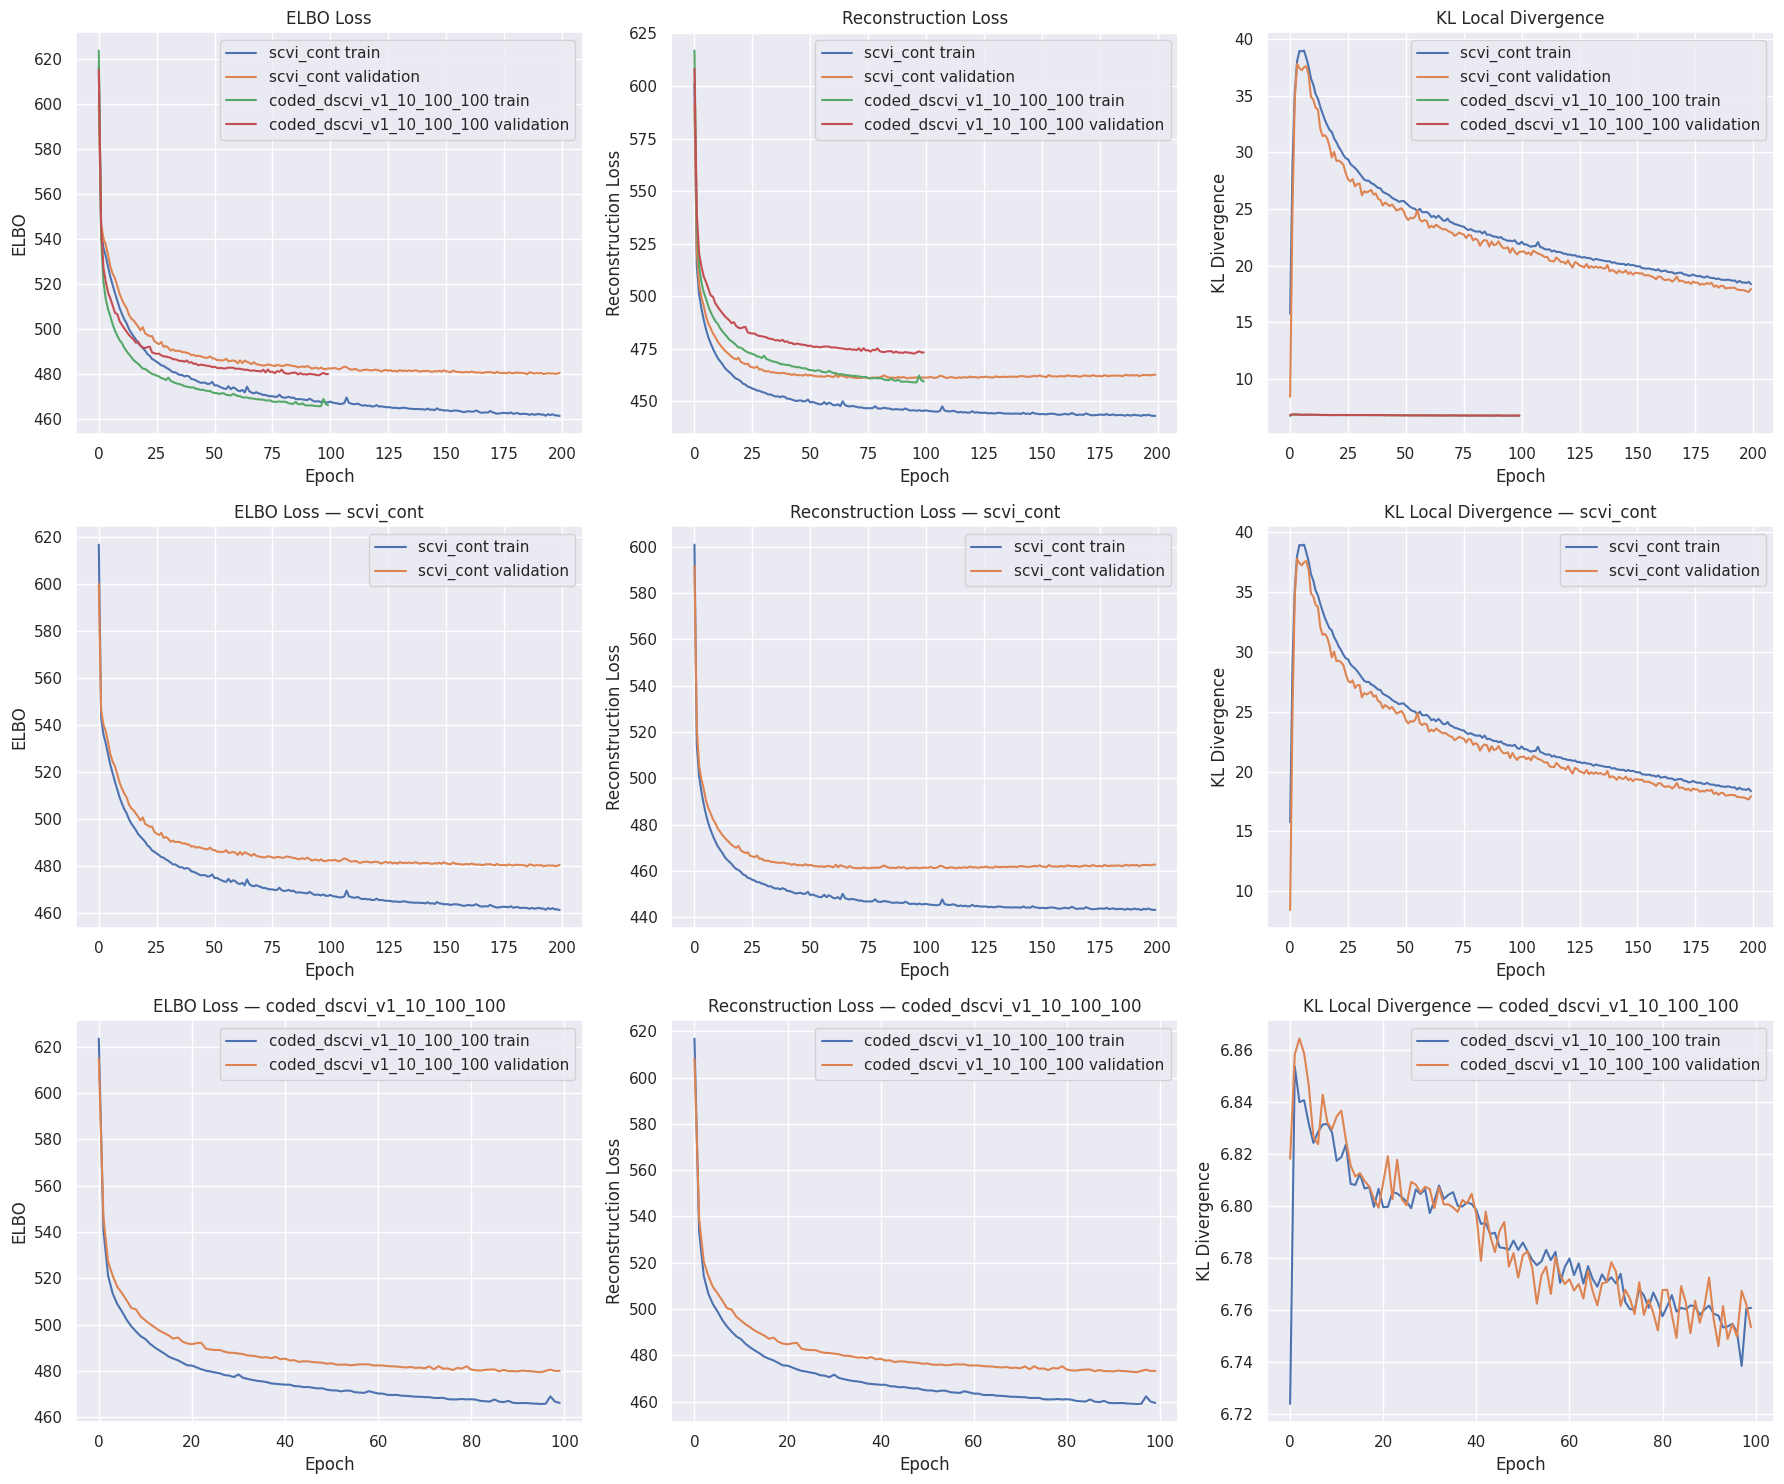

In [47]:
plot_loss_metrics(models_for_loss, model_name=f"{CONT_MODEL_NAME}_vs_{MODEL_NAME}", show=False)

## Investigate KL Divergence

KL Local Divergence did something it's not supposed to!
Update: Sampling process was wrong, now works. Jagged loss on kl but now it goes down instead of plateauing.

Lately, it plateaus again.


## Verify correct implementation

In [32]:
# Get a batch of real cells from your trained model's data loader
coded_model.module.eval()
test_loader = coded_model._make_data_loader(adata=adata, batch_size=256)
batch = next(iter(test_loader))
x_batch = batch[REGISTRY_KEYS.X_KEY]

In [33]:
with torch.no_grad():
    inf_out = coded_model.module.inference(x_batch, batch_index=batch[REGISTRY_KEYS.BATCH_KEY])
    qz = inf_out[MODULE_KEYS.QZ_KEY]
    qi = qz.probs if isinstance(qz, Bernoulli) else qz

In [34]:
# So this is the p(z|c) since it has dimension 100
qz
# Bernoulli(probs: torch.Size([256, 100]))
# type torch.distributions.bernoulli.Bernoulli
len(qi[0])
# 256 lists of length 100
# len 256
# type torch.Tensor

100

In [23]:
# p(z|c) - dimensions are good
samples = coded_model.get_latent_representation(adata, return_dist=True)
len(samples[0]), len(samples[1]) # (128, 128)
len(samples[0][0]) # 100

In [24]:
# p(m|x) - dimensions are correct
samples2 = coded_model.get_latent_representation(adata, return_dist=False, give_mean=True)
(samples2[0] == samples2[1]).sum() # np.int64(546)
len(samples2[0]), len(samples2[1]) # (128, 128)
len(samples2[0][0]) # 10

In [37]:
samples_bit = np.where(samples2[0] > 0.5, 1, 0)

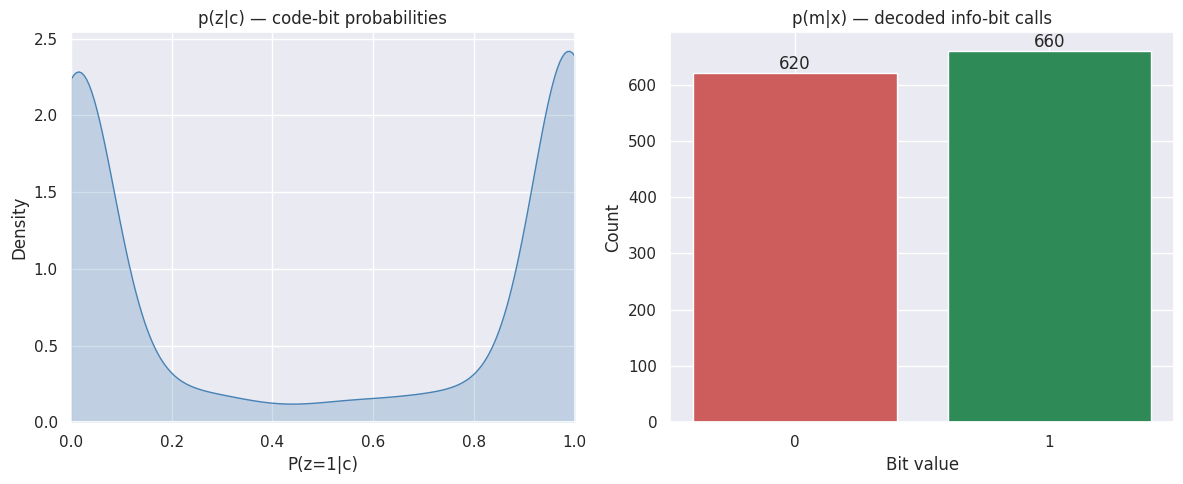

In [38]:
# Graph to visualize distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- p(z|c): continuous density over all 128*100 code-bit probabilities ---
qzc_probs = samples[0]  # mean, shape (128, 100)
sns.kdeplot(qzc_probs.flatten(), fill=True, ax=axes[0], color="steelblue", clip=(0, 1))
axes[0].set_title("p(z|c) — code-bit probabilities")
axes[0].set_xlabel("P(z=1|c)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 1)

# --- p(m|x): discrete 0/1 counts over all 128*10 info-bit calls ---
qmx_probs = samples2[0]  # mean, shape (128, 10)
samples_bit = np.where(qmx_probs > 0.5, 1, 0)
counts = np.bincount(samples_bit.flatten(), minlength=2)

axes[1].bar([0, 1], counts, color=["indianred", "seagreen"], tick_label=["0", "1"])
axes[1].set_title("p(m|x) — decoded info-bit calls")
axes[1].set_xlabel("Bit value")
axes[1].set_ylabel("Count")
for i, c in enumerate(counts):
    axes[1].text(i, c, str(c), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Latent Space

In [ ]:
# Generalized per-bit variance diagnostic (works for any model)
bit_report = per_bit_variance_report(coded_model, adata=adata, model_name=MODEL_NAME)
bit_report

In [ ]:
# Deterministic (mean) latent + sampled latent, both through get_latent()
latent_mean = get_latent(coded_model, give_mean=True)
latent_sampled = get_latent(coded_model, give_mean=False)

In [ ]:
latent_mean.shape, latent_sampled.shape

In [ ]:
# Push sampled latent to hard bits (0/1), same as `latent_bit` before,
# now reusable for any model via `binarize=True`
latent_bit = get_latent(coded_model, give_mean=False, binarize=True)
adata.obsm["Z_scVI"] = latent_bit

In [ ]:
means = pd.DataFrame(latent_bit)
means.columns = [f"z_{i}" for i in range(latent_bit.shape[1])]
means.index = adata.obs_names
means.head()

### LATENT SPACE INTERPRETABILITY

To investigate the interpretability of the latent space we look at the average value of each bit divided by cell type. This can show if information was learned, if the value is close to either 0 or 1. Furthermore, by also calculating the variance from that value I want to investigate the spread. Density plot could also work well, but to capture the variance what we will look at is the raw numerical deviation and the z-score which maps bit activation into a distribution.

For each cell type we compare to global mean.

In [ ]:
per_type_mean, deviation, zscore = plot_latent_heatmap(
    coded_model, adata, groupby="cell_type", model_name=MODEL_NAME
)

In [ ]:
per_type_mean, deviation, zscore = plot_latent_heatmap(
    cont_model, adata, groupby="cell_type", model_name="cont_model"
)

In [ ]:
print("Global mean per bit:\n", per_type_mean.mean(axis=0))
print("\nMax |z-score| per bit (cleanest dead-vs-alive metric):\n",
      max_abs_zscore_per_bit(zscore))

Why the z-score heatmap is the one that matters: the raw mean heatmap tells you activation level, but different bits can have very different baseline variance across the whole dataset. Dividing by global_std puts every bit on the same scale, so you can compare "how unusual is this cell type's activation of bit k" fairly across bits.

A truly dead bit looks like: same value for (nearly) every cell type, low variance across the population, and a z-score row/column that's uniformly near 0 everywhere. `max_abs_zscore_per_bit` above scans for exactly that (a bit is only worth calling dead if its max is small, e.g. under ~0.3-0.4, for every cell type).

### MATPLOTLIB UMAP


In [ ]:
# Compare as many latent spaces as you want side by side -- add more
# entries to this dict as you register more models.
latents_for_umap = {
    "Continuous (10-dim Gaussian)": get_latent(cont_model, give_mean=False),
    "Discrete uncoded (probs)": get_latent(coded_model, give_mean=False),
    "Discrete uncoded (bits)": latent_bit,
}
plot_umap_comparison(latents_for_umap, adata=adata, model_name=f"{CONT_MODEL_NAME}_vs_{MODEL_NAME}", show=False)

In [ ]:
# K-means on the bit latent, colored on its own UMAP
fig, cluster_labels = plot_umap_kmeans(
    latent_bit, model_name=MODEL_NAME, n_clusters=10, adata=adata
)
print(adata.obs["kmeans_clusters"].value_counts())
adata.obs.head()

To do - compare the color of clusters with the color of cell type (meaningful representation learned?)

### SCANPY UMAP PLOT

In [ ]:
import scanpy as sc
sc.set_figure_params(figsize=(6, 6), frameon=False)

In [ ]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)
sc.pl.umap(adata, color=["cell_type", "donor", "cell_source"], ncols=3, frameon=False)

In [ ]:
sc.pp.neighbors(adata, use_rep="Z_scVI")  # Using means of latent space z
sc.tl.umap(adata, min_dist=0.3)
sc.pl.umap(adata, color=["cell_type", "donor", "cell_source"], ncols=3, frameon=False)

### SCANPY T-SNE PLOT

In [ ]:
plot_tsne_scanpy(adata, use_rep="Z_scVI", color=["cell_type", "donor", "cell_source"], model_name=MODEL_NAME)

In [ ]:
# t-SNE with class mean + covariance ellipses, generalized to any obsm key
plot_tsne_with_ellipses(
    adata,
    use_rep="Z_scVI",
    groupby="cell_type",
    model_name=MODEL_NAME,
    xlim=(-100, 150),
    ylim=(200, -200),
    show=False
)